# The Pass Risk Lens: Pricing Every Pass in Expected Goals Conceded

**Analytics Cup 2.0 — Football**

Notebooks 06–08 kept landing on the same fact: the danger of losing the ball is decided mostly by
**where** it is lost. On its own that is a map a coach already half-knows. This notebook turns it into
a tool: for **every pass, and every option the passer had**, what could it cost if it goes wrong?

    risk   = P(pass fails) × expected cost of losing the ball where that pass would die
    reward = P(pass completes) × threat of the target

* `P(pass fails)` = 1 − SkillCorner's `xpass_completion` for that option.
* The **cost** of losing the ball at a point is ours: the chance the rival shoots within 15 s,
  learned from 2,435 open-play turnovers, converted to goals.
* **Where a pass would die** is ours too: learned from 1,277 real misplaced passes and replayed on
  each option's path, so options that were never played can still be priced.

The central test, fixed before looking: the risk score must predict which passes are followed by a
rival shot **better than SkillCorner's own failure probability alone**, on matches the model never saw.
Everything lives in [`src/pass_risk.py`](../src/pass_risk.py).


In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score
from mplsoccer import Pitch

from turnovers import load_or_build_turnovers
from pass_risk import (CostSurface, turnover_training_table, failed_pass_geometry, load_passing_options,
                       pass_outcomes, score_options)

pd.set_option("display.width", 150)
plt.rcParams["figure.dpi"] = 110
DATA_DIR = "../../skillcorner-opendata/data/matches"
turnovers, _ = load_or_build_turnovers(DATA_DIR, "../data/processed")
train = turnover_training_table(DATA_DIR, turnovers)
print(f"turnovers: {len(train)} | rival shots within 15 s: {train['shot_15s'].sum()} | goals: {train['goal_15s'].sum()}")


turnovers: 2435 | rival shots within 15 s: 120 | goals: 16


## 1. The cost surface

Four candidate models for P(rival shot within 15 s | where the ball was lost), compared on **held-out
matches** (5 folds of 4 matches: fit on 16, score the other 4). The simplest one that predicts best wins.

In [2]:
train["shot"], train["abs_y"] = train["shot_15s"].astype(int), train["loss_y"].abs()
formulas = {
    "thirds only": "shot ~ C(pd.cut(loss_x, [-60, -17.5, 17.5, 60]))",
    "linear in x and |y|": "shot ~ loss_x + abs_y",
    "spline in x + |y|": "shot ~ bs(loss_x, df=4, lower_bound=-53, upper_bound=53) + abs_y",
    "spline in x, x·|y|": "shot ~ bs(loss_x, df=4, lower_bound=-53, upper_bound=53) + abs_y + loss_x:abs_y",
}
matches = np.array(sorted(train["match_id"].unique()))
folds = np.array_split(np.random.default_rng(0).permutation(matches), 5)
rows, held_pred = {}, pd.Series(np.nan, index=train.index)
for name, f in formulas.items():
    pred = pd.Series(np.nan, index=train.index)
    for held in folds:
        m = smf.logit(f, data=train[~train["match_id"].isin(held)]).fit(disp=0)
        pred[train["match_id"].isin(held)] = m.predict(train[train["match_id"].isin(held)])
    rows[name] = {"AUC (held-out matches)": roc_auc_score(train["shot"], pred), "Brier": ((pred - train["shot"]) ** 2).mean()}
    if name == "linear in x and |y|":
        held_pred = pred
pd.DataFrame(rows).T.round(4)


,AUC (held-out matches),Brier
thirds only,0.6779,0.0457
linear in x and |y|,0.7388,0.0446
spline in x + |y|,0.7331,0.0448
"spline in x, x·|y|",0.7291,0.0447


In [3]:
cal = train.assign(pred=held_pred).groupby(pd.qcut(held_pred, 5), observed=True).agg(predicted=("pred", "mean"), observed=("shot", "mean"), n=("shot", "size"))
print("calibration of the chosen model on held-out matches:")
print(cal.round(3).to_string(index=False))
surface = CostSurface.fit(train)
print(f"\ngoals per rival shot after a turnover (conversion): {surface.goals_per_shot:.3f}")


calibration of the chosen model on held-out matches:
 predicted  observed   n
     0.011     0.010 487
     0.019     0.023 487
     0.031     0.031 487
     0.057     0.062 487
     0.128     0.121 487

goals per rival shot after a turnover (conversion): 0.133


The plain **logit in x and |y|** predicts held-out matches best and is well calibrated — extra
flexibility only fits noise. It is symmetric left/right on purpose: the left/right asymmetry seen in
Notebooks 07–08 had no mechanism and looked like noise. Converted to goals with the observed
16 goals / 120 shots after turnovers.

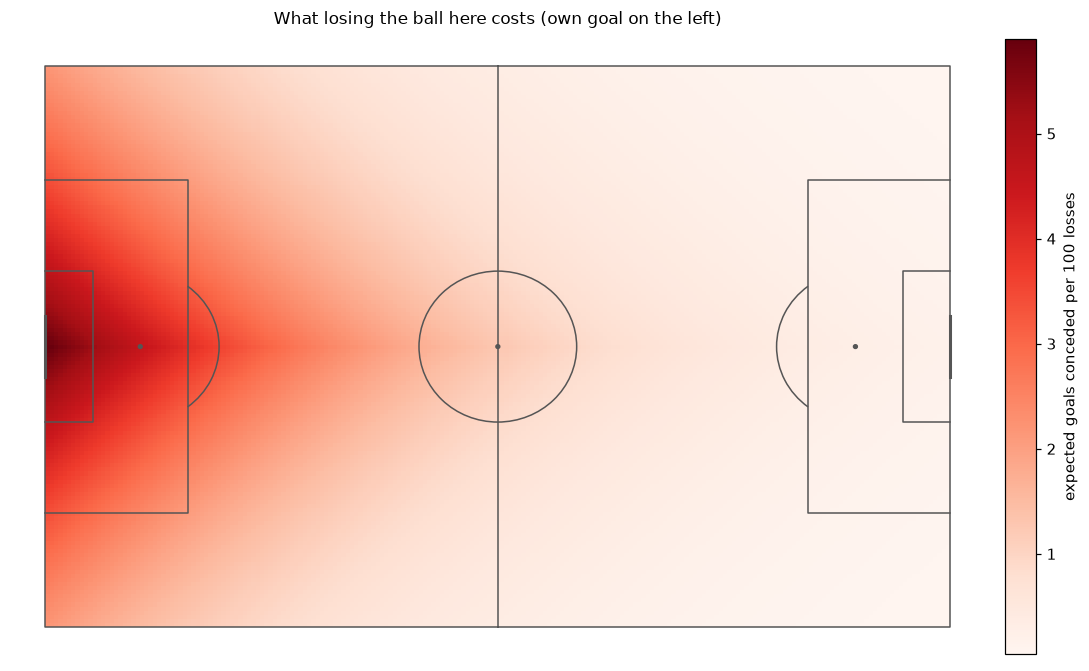

In [4]:
xs, ys = np.meshgrid(np.linspace(-52.5, 52.5, 211), np.linspace(-34, 34, 137))
fig, ax = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, line_color="#555555", linewidth=1, line_zorder=3).draw(figsize=(10, 6.2))
im = ax.imshow(surface.goals(xs, ys) * 100, extent=(-52.5, 52.5, -34, 34), origin="lower", cmap="Reds", zorder=1, aspect="auto")
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("expected goals conceded per 100 losses")
ax.set_title("What losing the ball here costs (own goal on the left)", fontsize=11)
plt.show()


## 2. Where failed passes die

Learned from real misplaced passes with a known intended receiver: the fraction of the path at which the rival won the ball, and how far off the passing line.

misplaced passes with passer, intended receiver and loss point: 1277 (median length 18 m)
lost before halfway 22% | halfway to receiver 43% | beyond the receiver 35% | median distance off the line 4.3 m


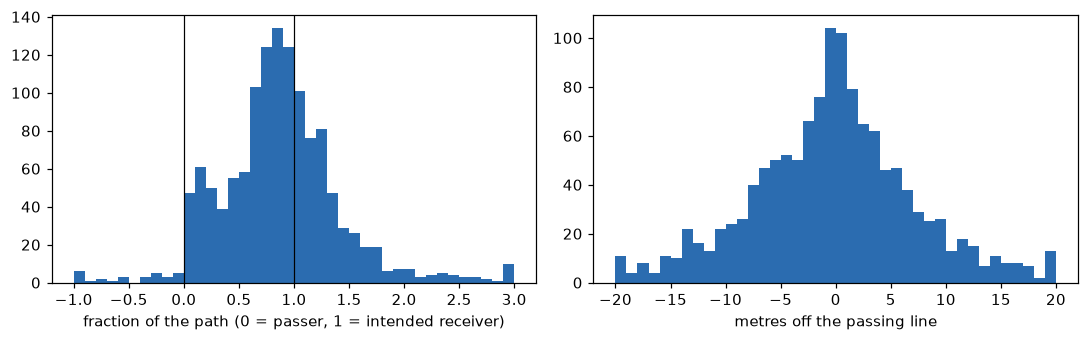

In [5]:
geometry = failed_pass_geometry(DATA_DIR, turnovers)
print(f"misplaced passes with passer, intended receiver and loss point: {len(geometry)} (median length {geometry['pass_len'].median():.0f} m)")
print(f"lost before halfway {np.mean(geometry['frac_along'] < .5):.0%} | halfway to receiver {np.mean((geometry['frac_along'] >= .5) & (geometry['frac_along'] <= 1)):.0%} "
      f"| beyond the receiver {np.mean(geometry['frac_along'] > 1):.0%} | median distance off the line {geometry['lateral_m'].abs().median():.1f} m")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(geometry["frac_along"].clip(-1, 3), bins=40, color="#2b6cb0"); ax[0].axvline(0, color="k", lw=.8); ax[0].axvline(1, color="k", lw=.8)
ax[0].set_xlabel("fraction of the path (0 = passer, 1 = intended receiver)")
ax[1].hist(geometry["lateral_m"].clip(-20, 20), bins=40, color="#2b6cb0"); ax[1].set_xlabel("metres off the passing line")
plt.tight_layout(); plt.show()


Most failed passes die **near the receiver**, not near the passer. Every passing option is priced by replaying these real failure shapes along its own path and averaging the cost over them.

## 3. The central test

Every passing option in the 20 matches is scored with a surface and a failure geometry learned **only from the other matches** (same 5 folds). Outcome of each pass actually played: did the rival shoot within 15 s?

In [6]:
options = load_passing_options(DATA_DIR)
outcomes = pass_outcomes(DATA_DIR)
scored = []
for held in folds:
    s = CostSurface.fit(train[~train["match_id"].isin(held)])
    scored.append(score_options(options[options["match_id"].isin(held)], s, geometry[~geometry["match_id"].isin(held)]))
scored = pd.concat(scored)
chosen = scored[scored["targeted"] == True].drop_duplicates("pass_key").merge(outcomes, on="pass_key")
y = chosen["rival_shot_15s"].astype(int).to_numpy()
print(f"passing options scored: {len(scored):,} | passes with the chosen option identified: {len(chosen):,} | followed by a rival shot: {y.sum()}")
scores = {"1 − xpass (SkillCorner only)": 1 - chosen["xpass"], "loss cost only (ours)": chosen["loss_cost"], "risk = (1 − xpass) × cost": chosen["risk"]}
pd.Series({k: roc_auc_score(y, v) for k, v in scores.items()}, name="AUC").round(3).to_frame()


passing options scored: 43,583 | passes with the chosen option identified: 15,160 | followed by a rival shot: 162


,AUC
1 − xpass (SkillCorner only),0.603
loss cost only (ours),0.625
risk = (1 − xpass) × cost,0.670


In [7]:
risk, fail, cost = chosen["risk"].to_numpy(), (1 - chosen["xpass"]).to_numpy(), chosen["loss_cost"].to_numpy()
mid = chosen["match_id"].to_numpy()
idx = {m: np.flatnonzero(mid == m) for m in np.unique(mid)}
rng = np.random.default_rng(7)
d_risk, d_cost = [], []
for _ in range(3000):
    i = np.concatenate([idx[m] for m in rng.choice(list(idx), len(idx))])
    if y[i].sum() == 0: continue
    base = roc_auc_score(y[i], fail[i])
    d_risk.append(roc_auc_score(y[i], risk[i]) - base); d_cost.append(roc_auc_score(y[i], cost[i]) - base)
for name, dd in [("risk vs SkillCorner only", d_risk), ("cost only vs SkillCorner only", d_cost)]:
    lo, hi = np.percentile(dd, [2.5, 97.5])
    print(f"{name:30s} AUC gain {np.mean(dd):+.3f}  95% CI (resampling whole matches) [{lo:+.3f}, {hi:+.3f}]")
wins = [roc_auc_score(y[i], risk[i]) > roc_auc_score(y[i], fail[i]) for i in idx.values() if 0 < y[i].sum() < len(i)]
print(f"risk beats SkillCorner-only in {sum(wins)} of {len(wins)} matches")


risk vs SkillCorner only       AUC gain +0.066  95% CI (resampling whole matches) [+0.038, +0.096]
cost only vs SkillCorner only  AUC gain +0.021  95% CI (resampling whole matches) [-0.059, +0.110]
risk beats SkillCorner-only in 16 of 20 matches


**The test passes.** Pricing *where* a pass would die adds real information to *whether* it
fails: the combined risk score predicts the passes followed by a rival shot clearly better than
SkillCorner's failure probability alone, with a confidence interval that resamples whole matches (the
strict version — passes of the same match aren't independent) and wins in most individual matches.
The cost on its own is **not** reliably better than SkillCorner alone — the value is in the
combination.

## 4. Does the value of the chosen pass line up with what happened next?

In [8]:
chosen["net"] = chosen["reward"] - chosen["risk"]
q = chosen.groupby(pd.qcut(chosen["net"], 5, labels=["lowest", "2", "3", "4", "highest"]), observed=True).agg(
    passes=("pass_key", "size"), own_shot_15s=("own_shot_15s", "mean"), rival_shot_15s=("rival_shot_15s", "mean"))
q.round(4)


,passes,own_shot_15s,rival_shot_15s
net,,,
lowest,3032,0.0224,0.0228
2,3032,0.0125,0.0096
3,3032,0.0313,0.0086
4,3032,0.0834,0.0082
highest,3032,0.2180,0.0043


The **rival-shot** side is a clean staircase: the higher the pass's value, the less often the rival
shoots within 15 s (2.3% → 1.0% → 0.9% → 0.8% → 0.4%) — this is the part our cost adds and section 3
validates. The **own-shot** side rises sharply at the top (8% and 22% in the two highest quintiles) but
isn't monotone at the bottom (the lowest-value quintile shoots slightly more often than the second);
that side leans on SkillCorner's threat model, not on anything this notebook built.

## 5. What the lens looks like on a real pass

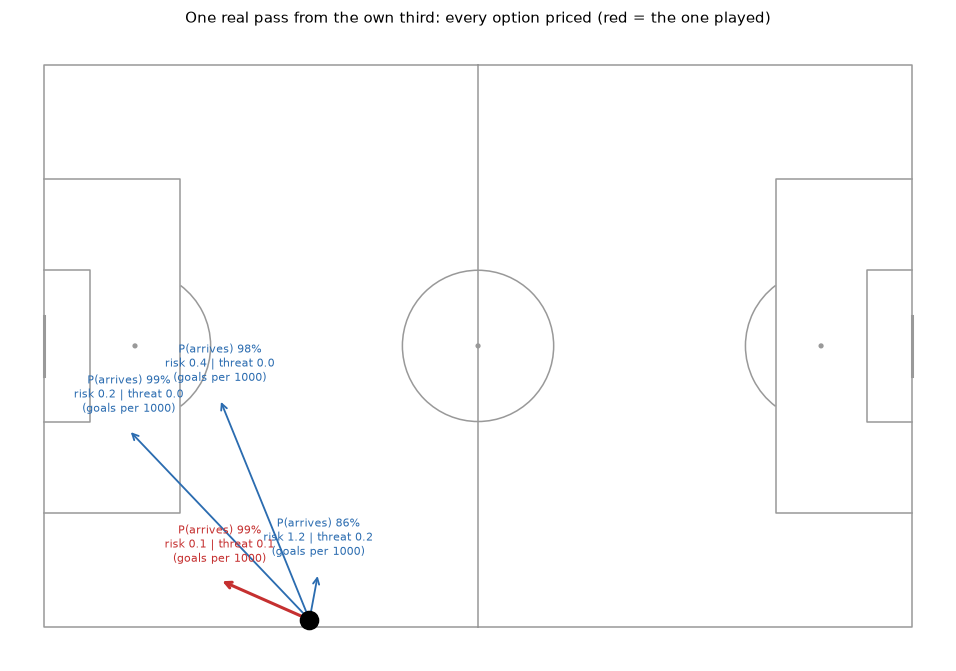

In [9]:
cand = scored.groupby("pass_key").filter(lambda g: len(g) >= 3)
cand = cand[(cand["px"] < -20)]
key = cand.sort_values(["match_id", "pass_key"])["pass_key"].unique()[5]
ex = scored[scored["pass_key"] == key]
fig, ax = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, line_color="#999999", linewidth=1).draw(figsize=(10, 6.2))
p = ex.iloc[0]
ax.scatter(p["px"], p["py"], s=140, color="black", zorder=4)
for _, r in ex.iterrows():
    colour = "#c53030" if r["targeted"] else "#2b6cb0"
    ax.annotate("", xy=(r["tx"], r["ty"]), xytext=(p["px"], p["py"]), arrowprops=dict(arrowstyle="->", color=colour, lw=2 if r["targeted"] else 1.2))
    ax.text(r["tx"], r["ty"] + 2.2, f"P(arrives) {r['xpass']:.0%}\nrisk {r['risk']*1000:.1f} | threat {r['reward']*1000:.1f}\n(goals per 1000)",
            fontsize=7.5, ha="center", color=colour, zorder=5)
ax.set_title("One real pass from the own third: every option priced (red = the one played)", fontsize=10)
plt.show()


## 6. What the lens does NOT do — tested and reported

Two natural extensions were tested with pre-specified criteria and **failed**; they are reported
because knowing where a tool stops is part of the tool.

* **"You should have played the other option."** Ranking options by threat − risk agrees with the
  option players actually chose **no more often than chance** (34.8% vs 36.0% random), for every number
  of options. Players pick the safest option (48%) far above chance. Unplayed options have no outcome,
  so there is no way to show the model's preferred option would have been better — and players see
  things the model doesn't (the receiver's pressure after control, the value of simply keeping the ball).
* **"Revealed risk appetite"** (a conditional-logit choice model of how much threat players demand per
  unit of risk). Threat + risk predicted held-out choices no better than safety alone (45.6% vs 45.0%),
  the threat coefficient came out *negative*, and the pre-specified face-validity check — teams that are
  **losing** should accept more risk than teams that are **winning** — was not confirmed, neither by the
  model nor by a simpler "safety given up" measure (intervals include zero).

The lens therefore prices risk; it doesn't pass verdicts. It shows the trade-off and leaves the decision
with the coach.


## 7. Summary

| Piece | Evidence |
|---|---|
| Cost of losing the ball by location | Simple logit, best on held-out matches, calibrated |
| Where failed passes die | 1,277 real misplaced passes; most die near the receiver |
| **Risk lens = SkillCorner failure probability × our cost** | Beats SkillCorner alone at predicting rival shots after a pass (match-resampled CI excludes 0; wins in most matches) |
| Value of the chosen pass vs what happened | Monotone on both sides |
| "Best option" verdicts, risk appetite | Tested, not supported — deliberately out of the tool |

### Limitations
* The cost measures **immediate** danger (a rival shot within 15 s). Losing the ball high costs little
  by this measure, but it still costs the attack; the lens doesn't price lost possession value.
* 20 matches of one league; goals per shot (0.133) comes from 16 goals — it scales every risk equally,
  so it changes the risk/threat balance but not which passes are riskiest.
* The options are those SkillCorner identifies (median 3 per pass); carrying or holding the ball are
  not in the choice set.
